In [1]:
import tensorflow as tf
import numpy as np
from PIL import Image

print("TensorFlow:", tf.__version__)
print("All OK!")

TensorFlow: 2.21.0
All OK!


In [2]:
import urllib.request
import zipfile
import os

print("Downloading PlantVillage dataset...")

url = "https://data.mendeley.com/public-files/datasets/tywbtsjrjv/files/d5652a28-c1d8-4b76-97f3-72fb80f94efc/file_downloaded"

# We'll use kaggle instead - let's first check our folder structure
for folder in ['data', 'model', 'app', 'notebooks']:
    path = os.path.join('..', folder)
    print(f"✓ {folder}/ exists:", os.path.exists(path))

✓ data/ exists: True
✓ model/ exists: True
✓ app/ exists: True
✓ notebooks/ exists: True


In [3]:
import os

# Set your kaggle token
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_e81df88c75d050c95671842162d8296e'

# Install kaggle
os.system("pip install kaggle")

# Create kaggle config folder
kaggle_dir = os.path.expanduser("~/.kaggle")
os.makedirs(kaggle_dir, exist_ok=True)

# Save token as kaggle.json (required format)
import json
token_data = {
    "username": "shifaiqbal",  # replace with your kaggle username
    "key": "KGAT_e81df88c75d050c95671842162d8296e"  # your token
}

with open(os.path.join(kaggle_dir, "kaggle.json"), "w") as f:
    json.dump(token_data, f)

print("Kaggle configured successfully!")

Kaggle configured successfully!


In [4]:
import os

# Set path to save dataset
data_path = os.path.join('..', 'data')

# Download PlantVillage dataset from Kaggle
os.system(f'kaggle datasets download -d emmarex/plantdisease -p {data_path}')

print("Download started... this may take 5-10 minutes depending on internet speed.")
print("File will be saved in your data/ folder.")

Download started... this may take 5-10 minutes depending on internet speed.
File will be saved in your data/ folder.


In [5]:
import os

data_path = os.path.join('..', 'data')

# Check what's in the data folder
files = os.listdir(data_path)

if files:
    for f in files:
        size = os.path.getsize(os.path.join(data_path, f))
        print(f"Found: {f} — Size: {size/1024/1024:.1f} MB")
else:
    print("Data folder is empty — download may have failed")

Found: plantdisease.zip — Size: 657.6 MB


In [6]:
import zipfile
import os

data_path = os.path.join('..', 'data')
zip_path = os.path.join(data_path, 'plantdisease.zip')

print("Extracting dataset... please wait.")

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(data_path)

print("Extraction complete!")

# See what got extracted
for item in os.listdir(data_path):
    print("→", item)

Extracting dataset... please wait.
Extraction complete!
→ plantdisease.zip
→ PlantVillage


In [7]:
import os

data_path = os.path.join('..', 'data', 'PlantVillage')

# See all disease categories
categories = os.listdir(data_path)
categories.sort()

print(f"Total disease categories: {len(categories)}")
print("\nAll categories:")
for i, cat in enumerate(categories):
    # Count images in each category
    cat_path = os.path.join(data_path, cat)
    num_images = len(os.listdir(cat_path))
    print(f"{i+1:2}. {cat} — {num_images} images")

Total disease categories: 16

All categories:
 1. Pepper__bell___Bacterial_spot — 997 images
 2. Pepper__bell___healthy — 1478 images
 3. PlantVillage — 15 images
 4. Potato___Early_blight — 1000 images
 5. Potato___Late_blight — 1000 images
 6. Potato___healthy — 152 images
 7. Tomato_Bacterial_spot — 2127 images
 8. Tomato_Early_blight — 1000 images
 9. Tomato_Late_blight — 1909 images
10. Tomato_Leaf_Mold — 952 images
11. Tomato_Septoria_leaf_spot — 1771 images
12. Tomato_Spider_mites_Two_spotted_spider_mite — 1676 images
13. Tomato__Target_Spot — 1404 images
14. Tomato__Tomato_YellowLeaf__Curl_Virus — 3209 images
15. Tomato__Tomato_mosaic_virus — 373 images
16. Tomato_healthy — 1591 images


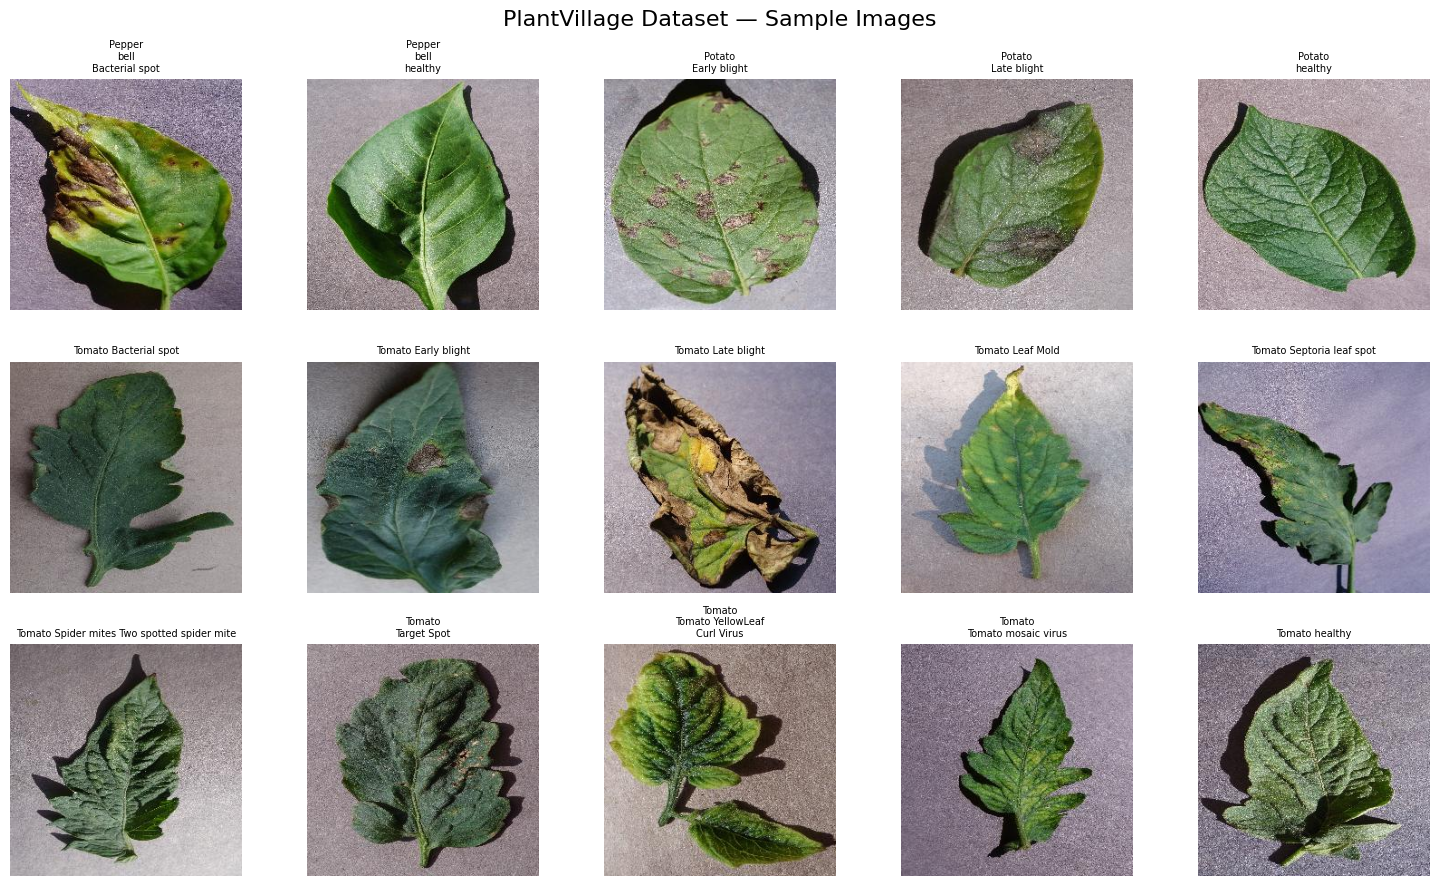

Sample images displayed!


In [8]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import random

data_path = os.path.join('..', 'data', 'PlantVillage')

# Remove the junk category
categories = [c for c in os.listdir(data_path) if c != 'PlantVillage']
categories.sort()

# Show sample images from different categories
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
fig.suptitle('PlantVillage Dataset — Sample Images', fontsize=16)

for i, ax in enumerate(axes.flat):
    if i < len(categories):
        cat = categories[i]
        cat_path = os.path.join(data_path, cat)
        img_file = random.choice(os.listdir(cat_path))
        img = Image.open(os.path.join(cat_path, img_file))
        ax.imshow(img)
        # Clean up label for display
        label = cat.replace('___', '\n').replace('__', '\n').replace('_', ' ')
        ax.set_title(label, fontsize=7)
        ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join('..', 'data', 'dataset_samples.png'), dpi=150)
plt.show()
print("Sample images displayed!")

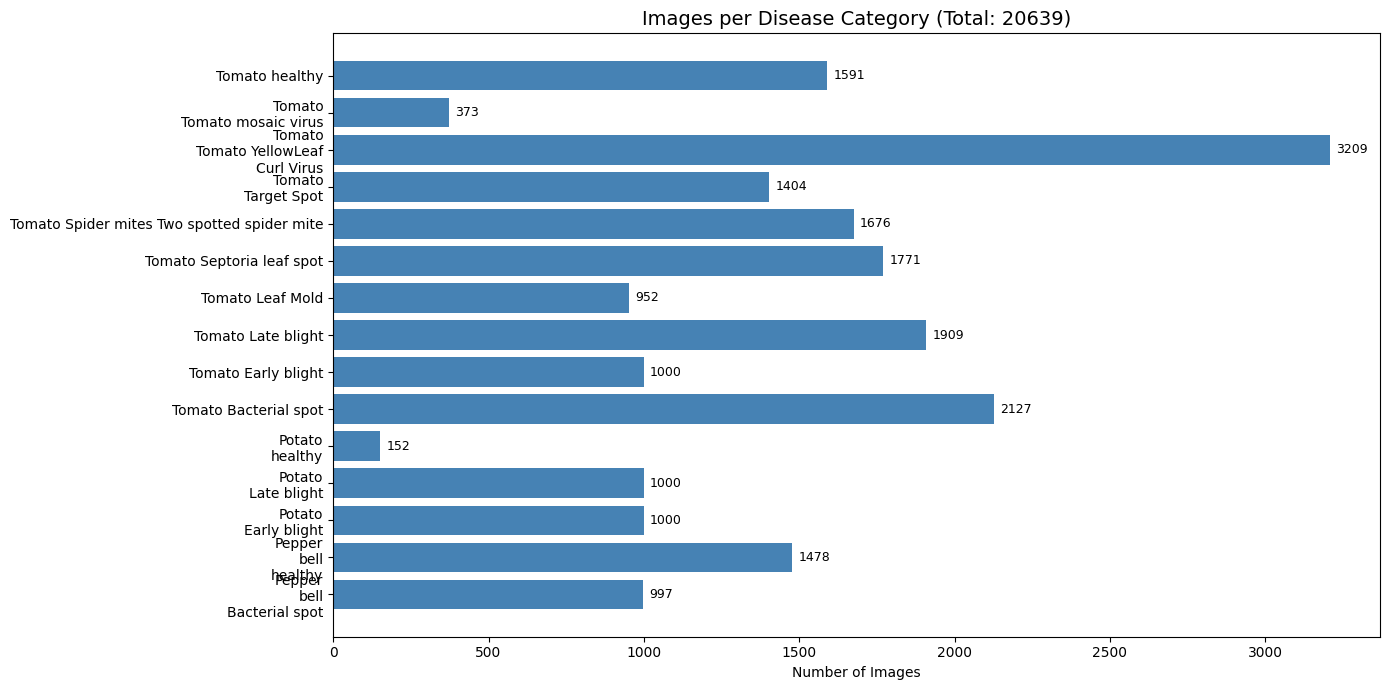


Total images: 20639
Total categories: 15
Average images per category: 1375


In [9]:
import os
import matplotlib.pyplot as plt

data_path = os.path.join('..', 'data', 'PlantVillage')

# Remove junk category
categories = [c for c in os.listdir(data_path) if c != 'PlantVillage']
categories.sort()

# Count images per category
counts = []
for cat in categories:
    cat_path = os.path.join(data_path, cat)
    counts.append(len(os.listdir(cat_path)))

total = sum(counts)

# Clean labels for display
clean_labels = [c.replace('___', '\n').replace('__', '\n').replace('_', ' ') 
                for c in categories]

# Plot
fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(clean_labels, counts, color='steelblue')
ax.set_xlabel('Number of Images')
ax.set_title(f'Images per Disease Category (Total: {total})', fontsize=14)

# Add count labels on bars
for bar, count in zip(bars, counts):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            str(count), va='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join('..', 'data', 'distribution.png'), dpi=150)
plt.show()

print(f"\nTotal images: {total}")
print(f"Total categories: {len(categories)}")
print(f"Average images per category: {total//len(categories)}")